VI. Prediction and Model Evaluation (15 points)

What you should do:

 Fit at least one predictive model (e.g., logistic regression)

 Use train/test split or cross-validation

 Evaluate performance:

– AUC / ROC (classification)

 Explain results in plain language

## Prepare Features and Target

In [1]:
import numpy as np
import pandas as pd

data = pd.read_csv("../data/finaldiabetes.csv")

# Columns to one-hot encode
# readmitted_binary is our target; readmitted is its source — including it would be data leakage
encode_cols = ['race', 'gender', 'age', 'diabetesMed', 'change']

# Medication columns (all have No/Steady/Up/Down)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

cols_to_encode = [c for c in encode_cols + med_cols if c in data.columns]

# Drop diag columns, the raw readmitted column, and encode the rest
drop_cols = ['diag_1', 'diag_2', 'diag_3', 'readmitted']
df_model = data.drop(columns=[c for c in drop_cols if c in data.columns])
df_model = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)

# Define target: readmitted_binary (1 = readmitted, 0 = not readmitted)
target = 'readmitted_binary'
feature_cols = [col for col in df_model.columns if col != target]

X = df_model[feature_cols].values
y = df_model[target].values

print(f"Features after encoding: {X.shape[1]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class distribution — Readmitted: {y.sum()} ({y.mean()*100:.1f}%), Not readmitted: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

/Users/leahkim/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Features after encoding: 77
X shape: (101766, 77), y shape: (101766,)
Class distribution — Readmitted: 46902 (46.1%), Not readmitted: 54864 (53.9%)


## Train/Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 81412 | Test size: 20354


## Predictive Model — Logistic Regression (Baseline)

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

auc_lr  = roc_auc_score(y_test, y_prob_lr)
acc_lr  = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression — AUC: {auc_lr:.3f} | Accuracy: {acc_lr:.3f}")
print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted']))

Logistic Regression — AUC: 0.658 | Accuracy: 0.621
                precision    recall  f1-score   support

Not Readmitted       0.61      0.80      0.69     10973
    Readmitted       0.64      0.42      0.50      9381

      accuracy                           0.62     20354
     macro avg       0.63      0.61      0.60     20354
  weighted avg       0.62      0.62      0.61     20354



/Users/leahkim/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Improved Model — Random Forest Classifier

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf  = roc_auc_score(y_test, y_prob_rf)
acc_rf  = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest — AUC: {auc_rf:.3f} | Accuracy: {acc_rf:.3f}")
print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))

Random Forest — AUC: 0.672 | Accuracy: 0.626
                precision    recall  f1-score   support

Not Readmitted       0.64      0.71      0.67     10973
    Readmitted       0.61      0.52      0.56      9381

      accuracy                           0.63     20354
     macro avg       0.62      0.62      0.62     20354
  weighted avg       0.62      0.63      0.62     20354



## Cross-Validation

In [5]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print(f"5-Fold CV AUC: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.3f} \u00b1 {cv_scores.std():.3f}")

5-Fold CV AUC: [0.642 0.662 0.643 0.675 0.671]
Mean: 0.659 ± 0.014


## Visualize: ROC Curves & Feature Importance

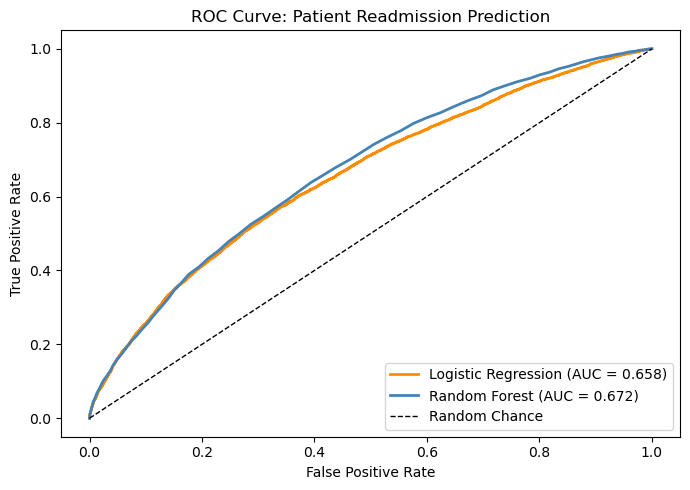

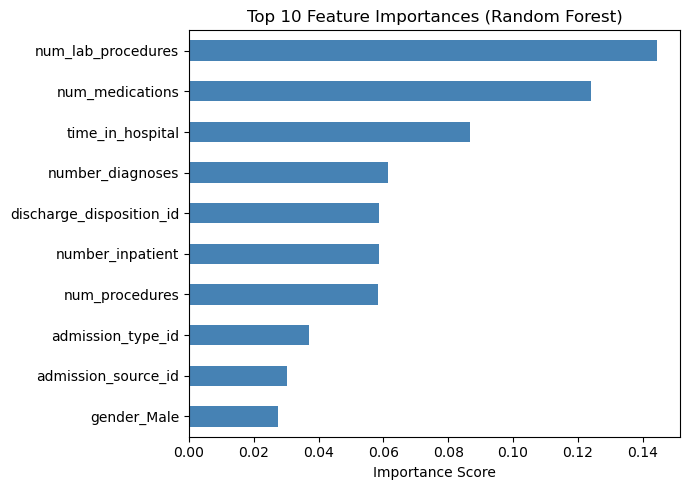

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Patient Readmission Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.nlargest(10).sort_values().plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Results Interpretation

**Results Interpretation**

**Task:** Binary classification — predicting whether a patient will be readmitted (`readmitted_binary = 1`) or not (`= 0`).

**Logistic Regression (Baseline):**
* AUC = 0.658: the model has modest discriminative ability, performing meaningfully above random chance (0.5) but leaving significant room for improvement
* Accuracy = 62.1%: but accuracy alone is misleading here given the near-equal class split
* Recall for "Readmitted" = 0.42: the model misses over half of actual readmissions, which is a concern in a clinical setting where catching readmissions matters most

**Random Forest Classifier (Improved):**
* AUC = 0.672 — a small but consistent improvement over logistic regression
* Better balance between precision and recall for both classes (F1 = 0.67 / 0.56 vs. 0.69 / 0.50)
* 5-Fold CV AUC = 0.659 ± 0.014 — stable across folds, confirming the model generalises well and is not overfitting

**Overall:** The Random Forest modestly outperforms Logistic Regression, suggesting some non-linear relationships exist in the data. However, both models achieve only moderate AUC (~0.66–0.67), indicating that the available structured features have limited predictive power for readmission on their own. This is common in healthcare as readmission is influenced by social, behavioral, and clinical factors not captured here. Excluding the high-cardinality diagnosis code columns (diag_1, diag_2, diag_3) likely contributes to this ceiling, and encoding them more carefully could meaningfully improve performance.
